In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
import requests

# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/life-expectancy-vs-gdp-per-capita.csv?v=1&csvType=full", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/life-expectancy-vs-gdp-per-capita.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

print(metadata)

{'chart': {'title': 'Life expectancy vs. GDP per capita', 'subtitle': 'The [period life expectancy](#dod:period-life-expectancy) at birth, in a given year. GDP per capita is adjusted for inflation and differences in living costs between countries.', 'note': 'GDP per capita is expressed in [international-$](#dod:int_dollar_abbreviation) at 2011 prices.', 'citation': 'Riley (2005); Zijdeman et al. (2015); HMD (2025); UN WPP (2024); Bolt and van Zanden – Maddison Project Database 2023', 'originalChartUrl': 'https://ourworldindata.org/grapher/life-expectancy-vs-gdp-per-capita?v=1&csvType=full&useColumnShortNames=true', 'selection': []}, 'columns': {'life_expectancy_0': {'titleShort': 'Life expectancy', 'titleLong': 'Life expectancy - Riley; Zijdeman et al.; HMD; UN WPP – Long-run data', 'descriptionShort': '[Period life expectancy](#dod:period-life-expectancy) is the number of years the average person born in a certain year would live if they experienced the same chances of dying at each a

In [27]:
# Print column names and their short descriptions from the existing metadata
for col_name, col_info in metadata.get("columns", {}).items():
    desc = col_info.get("descriptionShort") or col_info.get("titleLong") or "No description available."
    print(f"{col_name}: {desc}\n")

life_expectancy_0: [Period life expectancy](#dod:period-life-expectancy) is the number of years the average person born in a certain year would live if they experienced the same chances of dying at each age as people did that year.

gdp_per_capita: Average economic output per person in a country or region per year. This data is adjusted for inflation and differences in living costs between countries.

population_historical: Population by country, available from 10,000 BCE to 2023, based on data and estimates from different sources.

owid_region: Regions defined by Our World in Data, which are used in OWID charts and maps.

900793-annotations: 900793-annotations



In [11]:
df.head()

,Entity,Code,Year,Life expectancy at birth,GDP per capita,Population,World region according to OWID,GDP per capita (Annotations)
0,Afghanistan,AFG,1950,28.1563,1156.0,7776180.0,Asia,NaN
1,Afghanistan,AFG,1951,28.5836,1170.0,7879343.0,Asia,NaN
2,Afghanistan,AFG,1952,29.0138,1189.0,7987784.0,Asia,NaN
3,Afghanistan,AFG,1953,29.4521,1240.0,8096703.0,Asia,NaN
4,Afghanistan,AFG,1954,29.6975,1245.0,8207954.0,Asia,NaN


In [ ]:
# Clean the data (keep only rows where both GDP and Life Expectancy exist)
df_clean = df.dropna(subset=['Life expectancy at birth', 'GDP per capita'])

print("--- GENERAL STATISTICS ---")
print(f"Total valid records: {len(df_clean)}")
print(f"Years covered: {df_clean['Year'].min()} to {df_clean['Year'].max()}\n")

# Global Correlation
correlation = df_clean['Life expectancy at birth'].corr(df_clean['GDP per capita'])
print("--- CORRELATION ---")
print(f"Correlation between GDP per capita and Life Expectancy: {correlation:.4f} \n(Note: 1.0 is a perfect positive correlation)\n")

# Min and Max Values (Historical)
max_le_row = df_clean.loc[df_clean['Life expectancy at birth'].idxmax()]
min_le_row = df_clean.loc[df_clean['Life expectancy at birth'].idxmin()]
max_gdp_row = df_clean.loc[df_clean['GDP per capita'].idxmax()]

print("--- HISTORICAL EXTREMES ---")
print(f"Highest Life Expectancy: {max_le_row['Life expectancy at birth']:.1f} years ({max_le_row['Entity']}, {max_le_row['Year']})")
print(f"Lowest Life Expectancy: {min_le_row['Life expectancy at birth']:.1f} years ({min_le_row['Entity']}, {min_le_row['Year']})")
print(f"Highest GDP per Capita: ${max_gdp_row['GDP per capita']:.2f} ({max_gdp_row['Entity']}, {max_gdp_row['Year']})\n")

# Recent Year Insights (using the most recent year available in the cleaned data)
latest_year = df_clean['Year'].max()
df_latest = df_clean[df_clean['Year'] == latest_year]

print(f"--- INSIGHTS FOR THE MOST RECENT YEAR ({latest_year}) ---")
print(f"Global Average Life Expectancy: {df_latest['Life expectancy at birth'].mean():.1f} years")
print(f"Global Average GDP per Capita: ${df_latest['GDP per capita'].mean():.2f}")

# Finding Interesting Outliers in the latest year
# Example: High GDP but lower than average life expectancy
high_gdp_low_le = df_latest[(df_latest['GDP per capita'] > df_latest['GDP per capita'].mean()) & 
                            (df_latest['Life expectancy at birth'] < df_latest['Life expectancy at birth'].mean())]

# Example: Low GDP but higher than average life expectancy
low_gdp_high_le = df_latest[(df_latest['GDP per capita'] < df_latest['GDP per capita'].mean()) & 
                            (df_latest['Life expectancy at birth'] > df_latest['Life expectancy at birth'].mean())]

print("\n--- OUTLIERS IN RECENT YEAR ---")
print(f"Countries with Above-Average GDP but Below-Average Life Expectancy: {len(high_gdp_low_le)}")
if not high_gdp_low_le.empty:
    print("Examples:", ", ".join(high_gdp_low_le['Entity'].head(3).tolist()))

print(f"Countries with Below-Average GDP but Above-Average Life Expectancy: {len(low_gdp_high_le)}")
if not low_gdp_high_le.empty:
    print("Examples:", ", ".join(low_gdp_high_le['Entity'].head(3).tolist()))

--- GENERAL STATISTICS ---
Total valid records: 13239
Years covered: 1543 to 2022

--- CORRELATION ---
Correlation between GDP per capita and Life Expectancy: 0.6066 
(Note: 1.0 is a perfect positive correlation)

--- HISTORICAL EXTREMES ---
Highest Life Expectancy: 85.3 years (Hong Kong, 2019)
Lowest Life Expectancy: 11.3 years (Cambodia, 1977)
Highest GDP per Capita: $160051.23 (Qatar, 2016)

--- INSIGHTS FOR THE MOST RECENT YEAR (2022) ---
Global Average Life Expectancy: 72.7 years
Global Average GDP per Capita: $19778.71

--- OUTLIERS IN RECENT YEAR ---
Countries with Above-Average GDP but Below-Average Life Expectancy: 3
Examples: Equatorial Guinea, Russia, Seychelles
Countries with Below-Average GDP but Above-Average Life Expectancy: 35
Examples: Albania, Algeria, Argentina


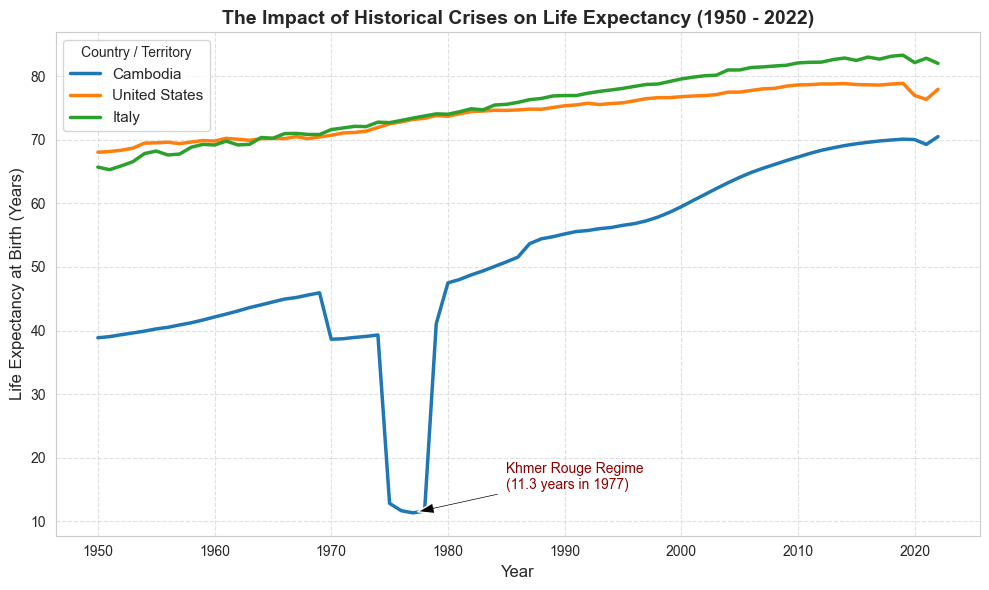

In [11]:
countries_to_plot = ['Cambodia', 'United States', 'Italy']
df_filtered = df[df['Entity'].isin(countries_to_plot)]
df_filtered = df_filtered[(df_filtered['Year'] >= 1950) & (df_filtered['Year'] <= 2022)]


# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

for country in countries_to_plot:
    country_data = df_filtered[df_filtered['Entity'] == country]
    # Drop NaNs just in case to avoid broken lines
    country_data = country_data.dropna(subset=['Year', 'Life expectancy at birth'])
    
    # Plotting the line for each country
    ax.plot(country_data['Year'], country_data['Life expectancy at birth'], 
            linewidth=2.5, label=country)

# 4. Formatting the chart
ax.set_title('The Impact of Historical Crises on Life Expectancy (1950 - 2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Life Expectancy at Birth (Years)', fontsize=12)
ax.legend(title='Country / Territory', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.6)

# Highlight the Cambodian drop in 1977
ax.annotate('Khmer Rouge Regime\n(11.3 years in 1977)', 
            xy=(1977, 11.3), xytext=(1985, 15),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1.5, headwidth=8),
            fontsize=10, color='darkred')

plt.tight_layout()
plt.show()

--- ITALY DECADAL TRENDS ---
1870s: Life Expectancy ~ 32.7 years | Avg GDP ~ $2682
1880s: Life Expectancy ~ 35.8 years | Avg GDP ~ $2949
1890s: Life Expectancy ~ 40.6 years | Avg GDP ~ $3089
1900s: Life Expectancy ~ 43.9 years | Avg GDP ~ $3534
1910s: Life Expectancy ~ 42.7 years | Avg GDP ~ $3856
1920s: Life Expectancy ~ 50.8 years | Avg GDP ~ $4314
1930s: Life Expectancy ~ 56.0 years | Avg GDP ~ $4700
1940s: Life Expectancy ~ 56.9 years | Avg GDP ~ $4296
1950s: Life Expectancy ~ 67.3 years | Avg GDP ~ $7270
1960s: Life Expectancy ~ 70.2 years | Avg GDP ~ $12199
1970s: Life Expectancy ~ 72.8 years | Avg GDP ~ $17514
1980s: Life Expectancy ~ 75.5 years | Avg GDP ~ $22593
1990s: Life Expectancy ~ 78.0 years | Avg GDP ~ $28395
2000s: Life Expectancy ~ 80.8 years | Avg GDP ~ $34529
2010s: Life Expectancy ~ 82.7 years | Avg GDP ~ $34361
2020s: Life Expectancy ~ 82.4 years | Avg GDP ~ $34479

--- SIGNIFICANT ANOMALIES ---
Largest drop in Life Expectancy: 1918 (-12.26 years)
Largest drop in 

C:\Users\amkhz\AppData\Local\Temp\ipykernel_13204\705064488.py:46: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


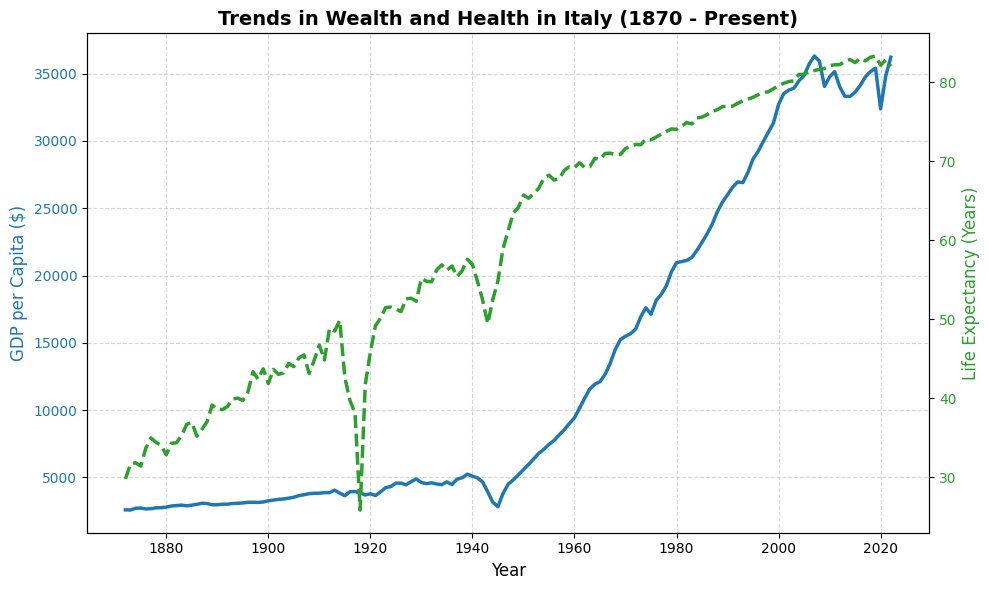

In [5]:
df_italy = df[df['Entity'] == 'Italy'].copy()
df_italy = df_italy.dropna(subset=['Year', 'Life expectancy at birth', 'GDP per capita'])
df_italy = df_italy.sort_values('Year')

# Print Decadal Trends for the Story
print("--- ITALY DECADAL TRENDS ---")
df_italy['Decade'] = (df_italy['Year'] // 10) * 10
decadal_summary = df_italy.groupby('Decade').agg(
    Avg_LE=('Life expectancy at birth', 'mean'),
    Avg_GDP=('GDP per capita', 'mean')
).reset_index()

for index, row in decadal_summary.iterrows():
    print(f"{int(row['Decade'])}s: Life Expectancy ~ {row['Avg_LE']:.1f} years | Avg GDP ~ ${row['Avg_GDP']:.0f}")

# Find Major Anomalies (Biggest drops)
df_italy['LE_Change'] = df_italy['Life expectancy at birth'].diff()
df_italy['GDP_Change'] = df_italy['GDP per capita'].diff()

worst_le_drop = df_italy.loc[df_italy['LE_Change'].idxmin()]
worst_gdp_drop = df_italy.loc[df_italy['GDP_Change'].idxmin()]

print("\n--- SIGNIFICANT ANOMALIES ---")
print(f"Largest drop in Life Expectancy: {int(worst_le_drop['Year'])} ({worst_le_drop['LE_Change']:.2f} years)")
print(f"Largest drop in GDP per Capita: {int(worst_gdp_drop['Year'])} (${worst_gdp_drop['GDP_Change']:.2f})")

# 5. Create the Visualization for the Slide
fig, ax1 = plt.subplots(figsize=(10, 6))

color1 = 'tab:blue'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('GDP per Capita ($)', color=color1, fontsize=12)
ax1.plot(df_italy['Year'], df_italy['GDP per capita'], color=color1, linewidth=2.5, label='GDP per Capita')
ax1.tick_params(axis='y', labelcolor=color1)
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = ax1.twinx()  
color2 = 'tab:green'
ax2.set_ylabel('Life Expectancy (Years)', color=color2, fontsize=12)
ax2.plot(df_italy['Year'], df_italy['Life expectancy at birth'], color=color2, linewidth=2.5, linestyle='--', label='Life Expectancy')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Trends in Wealth and Health in Italy (1870 - Present)', fontsize=14, fontweight='bold')
fig.tight_layout()

fig.show()

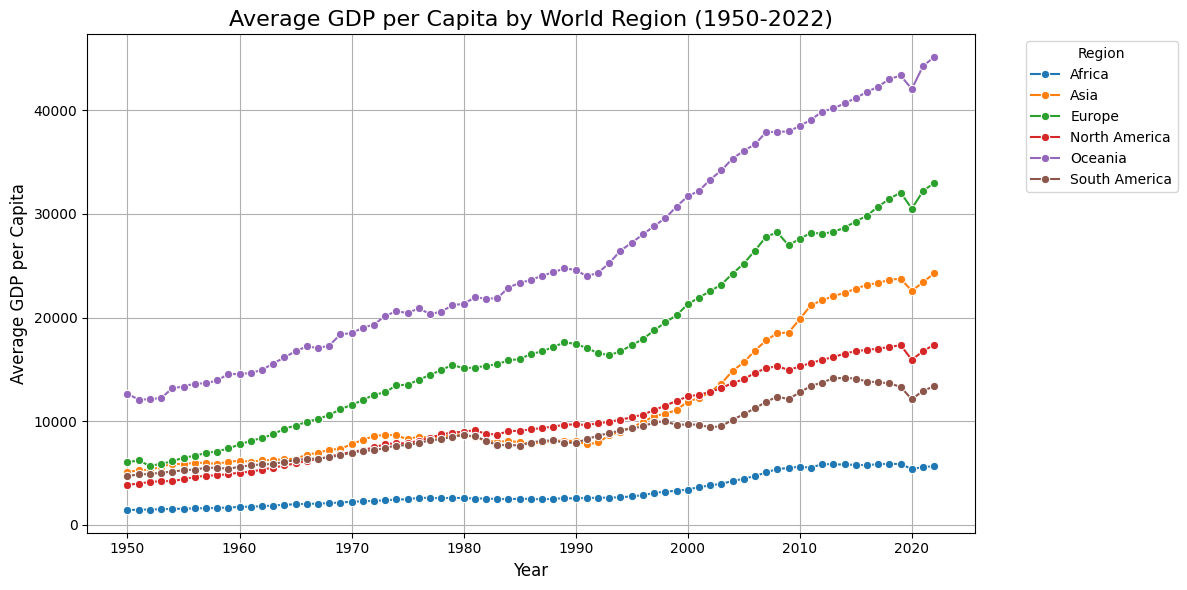

In [14]:
df_filtered = df[(df['Year'] >= 1950) & (df['Year'] <= 2022)]

# Drop rows where 'GDP per capita' or 'World region according to OWID' is missing
# As you mentioned lots of NaNs, this step is crucial
df_clean = df_filtered.dropna(subset=['GDP per capita', 'World region according to OWID'])

# Calculate the average GDP per capita for each region per year
# We use mean() here to get the regional average.
regional_gdp = df_clean.groupby(['World region according to OWID', 'Year'])['GDP per capita'].mean().reset_index()

# Set the figure size
plt.figure(figsize=(12, 6))

# Create the line chart
sns.lineplot(
    data=regional_gdp,
    x='Year',
    y='GDP per capita',
    hue='World region according to OWID',
    marker='o'
)

# Customize the plot
plt.title('Average GDP per Capita by World Region (1950-2022)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average GDP per Capita', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.show()

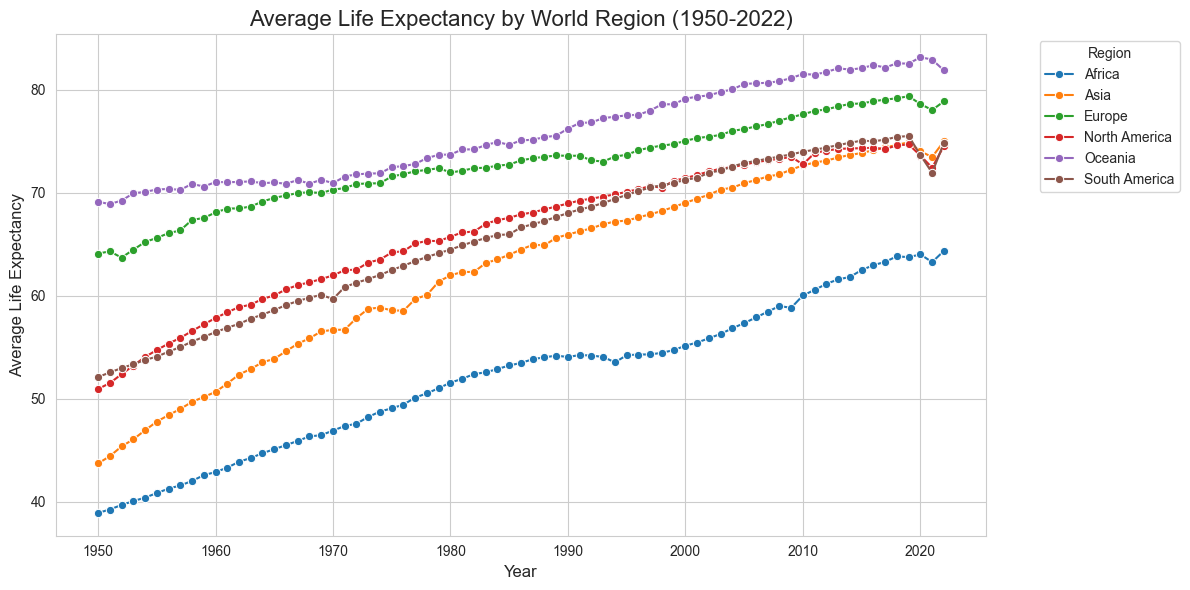

In [7]:
df_filtered = df[(df['Year'] >= 1950) & (df['Year'] <= 2022)]

# Drop rows where 'GDP per capita' or 'World region according to OWID' is missing
# As you mentioned lots of NaNs, this step is crucial
df_clean = df_filtered.dropna(subset=['GDP per capita', 'World region according to OWID'])

# Calculate the average life expectancy for each region per year
# We use mean() here to get the regional average.
regional_life = df_clean.groupby(['World region according to OWID', 'Year'])['Life expectancy at birth'].mean().reset_index()

# Set the figure size
plt.figure(figsize=(12, 6))

# Create the line chart
sns.lineplot(
    data=regional_life,
    x='Year',
    y='Life expectancy at birth',
    hue='World region according to OWID',
    marker='o'
)

# Customize the plot
plt.title('Average Life Expectancy by World Region (1950-2022)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Life Expectancy', fontsize=12)
plt.legend(title='Region', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.show()

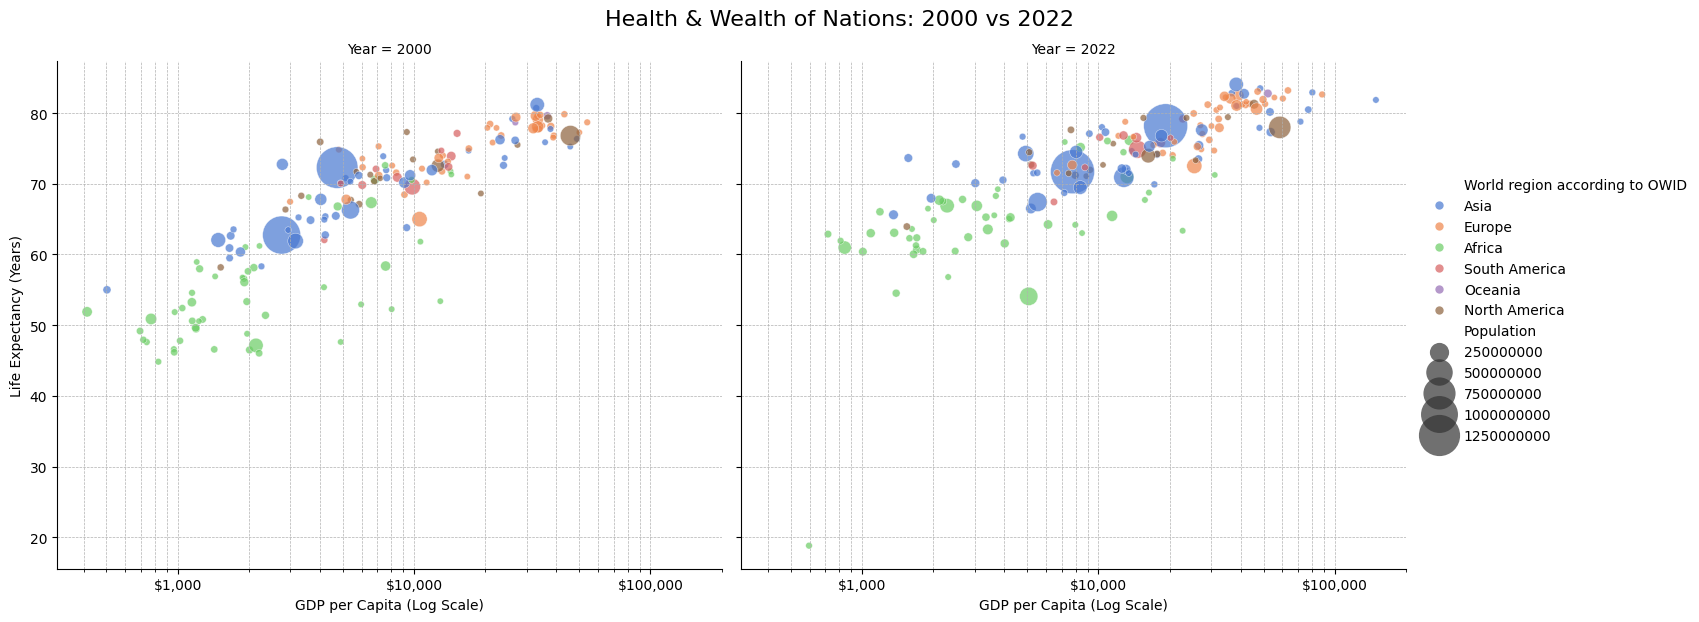

In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


# 1. Filter for the start and end years only
years_of_interest = [2000, 2022]
df_subset = df[df['Year'].isin(years_of_interest)].copy()

# 2. Drop rows with missing values for the chart
df_subset = df_subset.dropna(subset=['GDP per capita', 'Life expectancy at birth', 'Population', 'World region according to OWID'])

# 3. Create the Bubble Chart using relplot (allows for subplots/faceting)
g = sns.relplot(
    data=df_subset,
    x="GDP per capita",
    y="Life expectancy at birth",
    hue="World region according to OWID",
    size="Population",
    col="Year",             # Creates side-by-side charts
    kind="scatter",
    palette="muted",
    sizes=(20, 1000),       # Range of bubble sizes
    alpha=0.7,              # Transparency
    height=6,
    aspect=1.2
)

# 4. Apply Log Scale to X-axis (GDP) for better distribution
g.set(xscale="log")

# 5. Customizing titles and axes
g.set_axis_labels("GDP per Capita (Log Scale)", "Life Expectancy (Years)")
g.fig.suptitle('Health & Wealth of Nations: 2000 vs 2022', fontsize=16, y=1.03)

# 6. Formatting the tick labels to look like currency (optional)
from matplotlib.ticker import FuncFormatter
def currency_fmt(x, pos):
    return '${:,.0f}'.format(x)

for ax in g.axes.flat:
    ax.xaxis.set_major_formatter(FuncFormatter(currency_fmt))
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)

plt.savefig('health_wealth_bubble_chart.png', bbox_inches='tight')
plt.show()